# Import Libraries

In [28]:
import os

import re
import pandas as pd
import numpy as np

import segyio

import matplotlib.pyplot as plt

from skimage.transform import resize
from sklearn import model_selection

import sporco

from plot_functions import plot_results

In [2]:
def read_inline_segy_filenames(folder_path, direction, property):
   """
   Reads the names of files in the specified folder that start with "inline" and end with ".segy".

   Args:
       folder_path (str): The path to the folder containing the files.

   Returns:
       list: A list of qualifying filenames.
   """

   filenames = []
   for filename in os.listdir(folder_path):
        # Check if "inline" is a substring and ".segy" is at the end
        if direction in filename and filename.endswith(".segy") and property in filename:
            filename = os.path.join(folder_path, filename)
            filenames.append(filename)

   return filenames

In [3]:
def parse_trace_headers(segyfile, n_traces):
    '''
    Parse the segy file trace headers into a pandas dataframe.
    Column names are defined from segyio internal tracefield
    One row per trace
    '''
    # Get all header keys
    headers = segyio.tracefield.keys
    # Initialize dataframe with trace id as index and headers as columns
    df = pd.DataFrame(index=range(1, n_traces + 1),
                      columns=headers.keys())
    # Fill dataframe with all header values
    for k, v in headers.items():
        df[k] = segyfile.attributes(v)[:]
    return df


def parse_text_header(segyfile):
    '''
    Format segy text header into a readable, clean dict
    '''
    raw_header = segyio.tools.wrap(segyfile.text[0])
    # Cut on C*int pattern
    cut_header = re.split(r'C ', raw_header)[1::]
    # Remove end of line return
    text_header = [x.replace('\n', ' ') for x in cut_header]
    text_header[-1] = text_header[-1][:-2]
    # Format in dict
    clean_header = {}
    i = 1
    for item in text_header:
        key = "C" + str(i).rjust(2, '0')
        i += 1
        clean_header[key] = item
    return clean_header

In [4]:
folder_path = "data_decatur/lineas/"
folder_output = "data_decatur/processed/"

lines_impedance_inline = read_inline_segy_filenames(folder_path, 'inline', 'impedance')
lines_impedance_xline = read_inline_segy_filenames(folder_path, 'xline', 'impedance')
lines_porosity_inline = read_inline_segy_filenames(folder_path, 'inline', 'porosity')
lines_porosity_xline = read_inline_segy_filenames(folder_path, 'xline', 'porosity')



In [5]:
lines_impedance_inline.sort()
lines_impedance_xline.sort()
lines_porosity_inline.sort()
lines_porosity_xline.sort()

In [6]:
with segyio.open(lines_impedance_inline[0], ignore_geometry=True) as f:
            data = f.trace.raw[:] 
            traces_inline = data.shape[0]
            samples_inline = data.shape[1]

In [7]:
with segyio.open(lines_impedance_xline[0], ignore_geometry=True) as f:
            data = f.trace.raw[:] 
            traces_xline = data.shape[0]
            samples_xline = data.shape[1]

In [8]:
def load_seismic(lines, first_dimension, second_dimension, number_of_images):
    
    lines_array = np.empty(shape=(first_dimension,second_dimension,number_of_images))

    for index, line in enumerate(lines):
        with segyio.open(line, ignore_geometry=True) as f:
            data = f.trace.raw[:] 
            lines_array[:,:,index] = data

            del data
    return lines_array
    

In [9]:
lines_array_impedance_inline = load_seismic(lines_impedance_inline,traces_inline, samples_inline, len(lines_impedance_inline))
lines_array_impedance_xline = load_seismic(lines_impedance_xline,traces_xline, samples_xline, len(lines_impedance_xline))
lines_array_porosity_inline = load_seismic(lines_porosity_inline,traces_inline, samples_inline,  len(lines_impedance_inline))
lines_array_porosity_xline = load_seismic(lines_porosity_xline,traces_xline, samples_xline, len(lines_impedance_xline))

# Data Exploration

In [10]:
print(f"Las dimensiones en inline: son\nWidth: {lines_array_impedance_inline.shape[0]}\nHeight: {lines_array_impedance_inline.shape[1]}\n# Lineas: {lines_array_impedance_inline.shape[2]}")
print(f"Las dimensiones en xline: son\nWidth: {lines_array_impedance_xline.shape[0]}\nHeight: {lines_array_impedance_xline.shape[1]}\n# Lineas: {lines_array_impedance_xline.shape[2]}")

Las dimensiones en inline: son
Width: 1211
Height: 124
# Lineas: 3
Las dimensiones en xline: son
Width: 182
Height: 124
# Lineas: 4


In [11]:
n_inlines = lines_array_impedance_inline.shape[2]
n_xlines = lines_array_impedance_xline.shape[2]

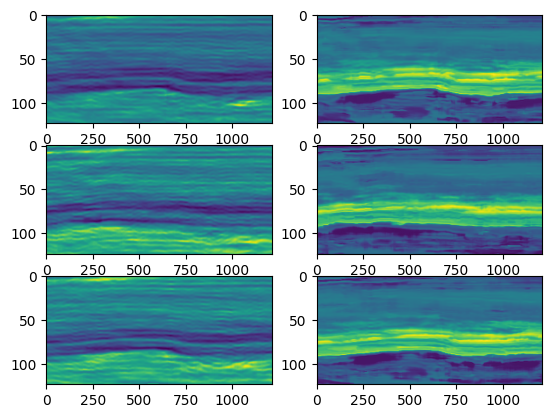

In [12]:
fig, ax = plt.subplots(n_inlines,2)

for i in range(0, n_inlines):
    ax[i, 0].imshow(lines_array_impedance_inline[:,:,i].T)
    ax[i, 0].set_aspect('auto')
    ax[i, 1].imshow(lines_array_porosity_inline[:,:,i].T)
    ax[i, 1].set_aspect('auto')
    
plt.show()

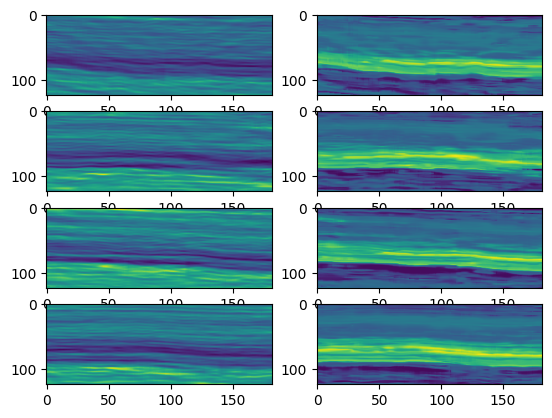

In [13]:
fig, ax = plt.subplots(n_xlines,2)

for i in range(0, n_xlines):
    ax[i, 0].imshow(lines_array_impedance_xline[:,:,i].T)
    ax[i, 0].set_aspect('auto')
    ax[i, 1].imshow(lines_array_porosity_xline[:,:,i].T)
    ax[i, 1].set_aspect('auto')
    
plt.show()

In [14]:
def lines_organization(inline, xline, size, step):
    inlines = sporco.array.extract_blocks(inline, (size,size), (step,))
    xlines = sporco.array.extract_blocks(xline, (size,size), (step,))
    array_conectado = np.concatenate((inlines, xlines), axis=2)
    return array_conectado

In [15]:
data_blocks_porosity = lines_organization(lines_array_porosity_inline, lines_array_porosity_xline, 32, 32)

data_blocks_impedance = lines_organization(lines_array_impedance_inline,lines_array_impedance_xline, 32, 32)


In [16]:
data_blocks_porosity.shape, data_blocks_impedance.shape

((32, 32, 12183), (32, 32, 12183))

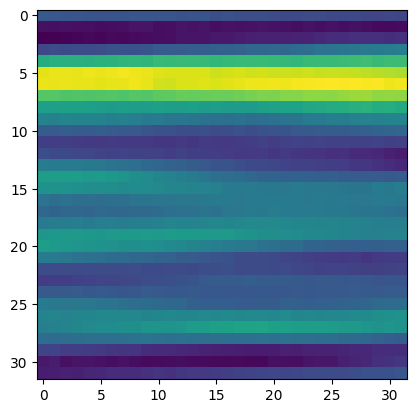

In [17]:
plt.imshow(data_blocks_impedance[:,:,0].T)

In [18]:
data_blocks_impedance[:,:,1].T.shape

(32, 32)

In [19]:
""" Este bloque de código asegura que las dimensiones de los arrays sean compatibles con como entran 
los datos a la red neuronal. Se organiza de tal forma que la primera dimension es la cantidad de 
imagenes que hay, la segunda es el numero de canales y la tercera es el ancho y alto de la figura"""

new_impedance = np.moveaxis(data_blocks_impedance, -1, 0)
new_new_impedance = np.moveaxis(new_impedance, 1, 2)

new_porosity = np.moveaxis(data_blocks_porosity, -1, 0)
new_new_porosity = np.moveaxis(new_porosity, 1, 2)

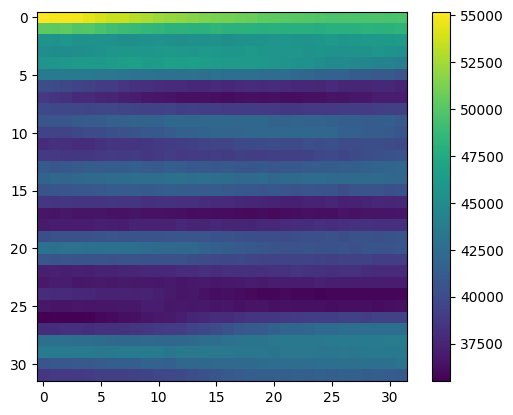

In [20]:
im = plt.imshow(new_new_impedance[20,:,:])
fig.colorbar(im)
plt.show()

In [21]:
new_new_impedance.shape

(12183, 32, 32)

# Data Exploration

## Porosity

In [22]:
np.count_nonzero(np.ravel(new_new_porosity)<0)

2490

In [23]:
len(np.ravel(new_new_porosity))

12475392

El error es 0.0
Las dimensiones del Y predict es (12183, 32, 32)
Las dimensiones del Y normal es (12183, 32, 32)


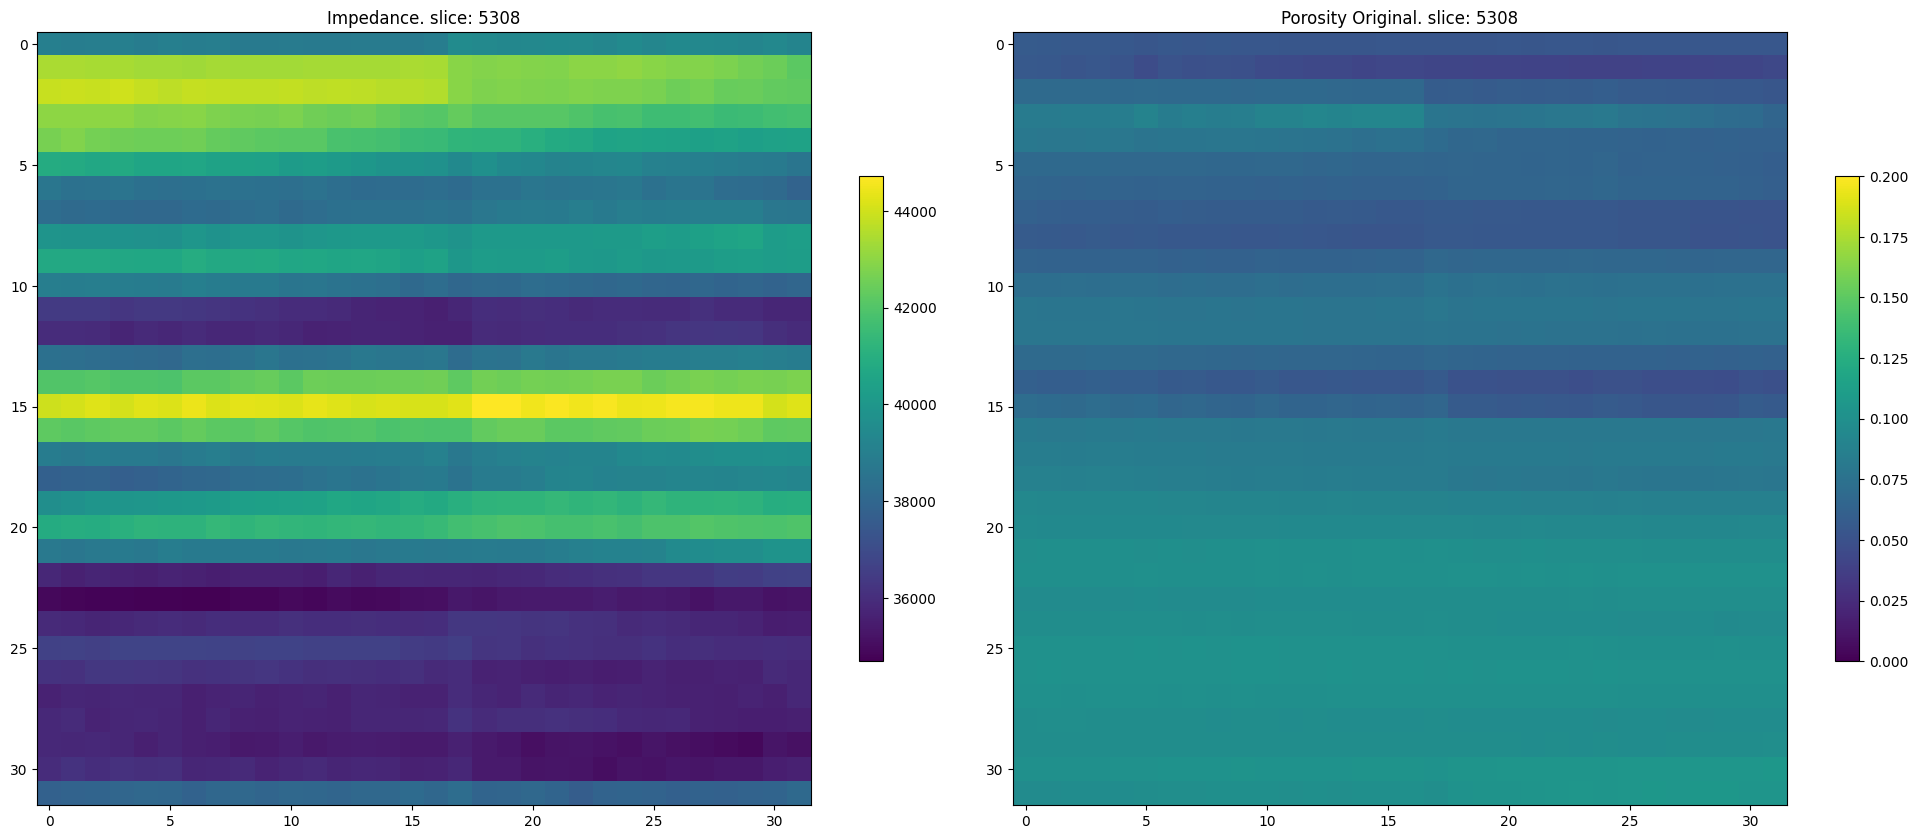

In [62]:
plot_results(new_new_impedance,new_new_porosity, new_new_porosity,False, False)

# Save Data

In [24]:
np.save(f'{folder_output}full_impedance.npy', new_new_impedance)
np.save(f'{folder_output}full_porosity.npy', new_new_porosity)

In [25]:
X_train,X_test,Y_train,Y_test = model_selection.train_test_split(new_new_impedance,new_new_porosity, test_size=0.20, random_state=1,shuffle=False)

El error es 0.0
Las dimensiones del Y predict es (9746, 32, 32)
Las dimensiones del Y normal es (9746, 32, 32)


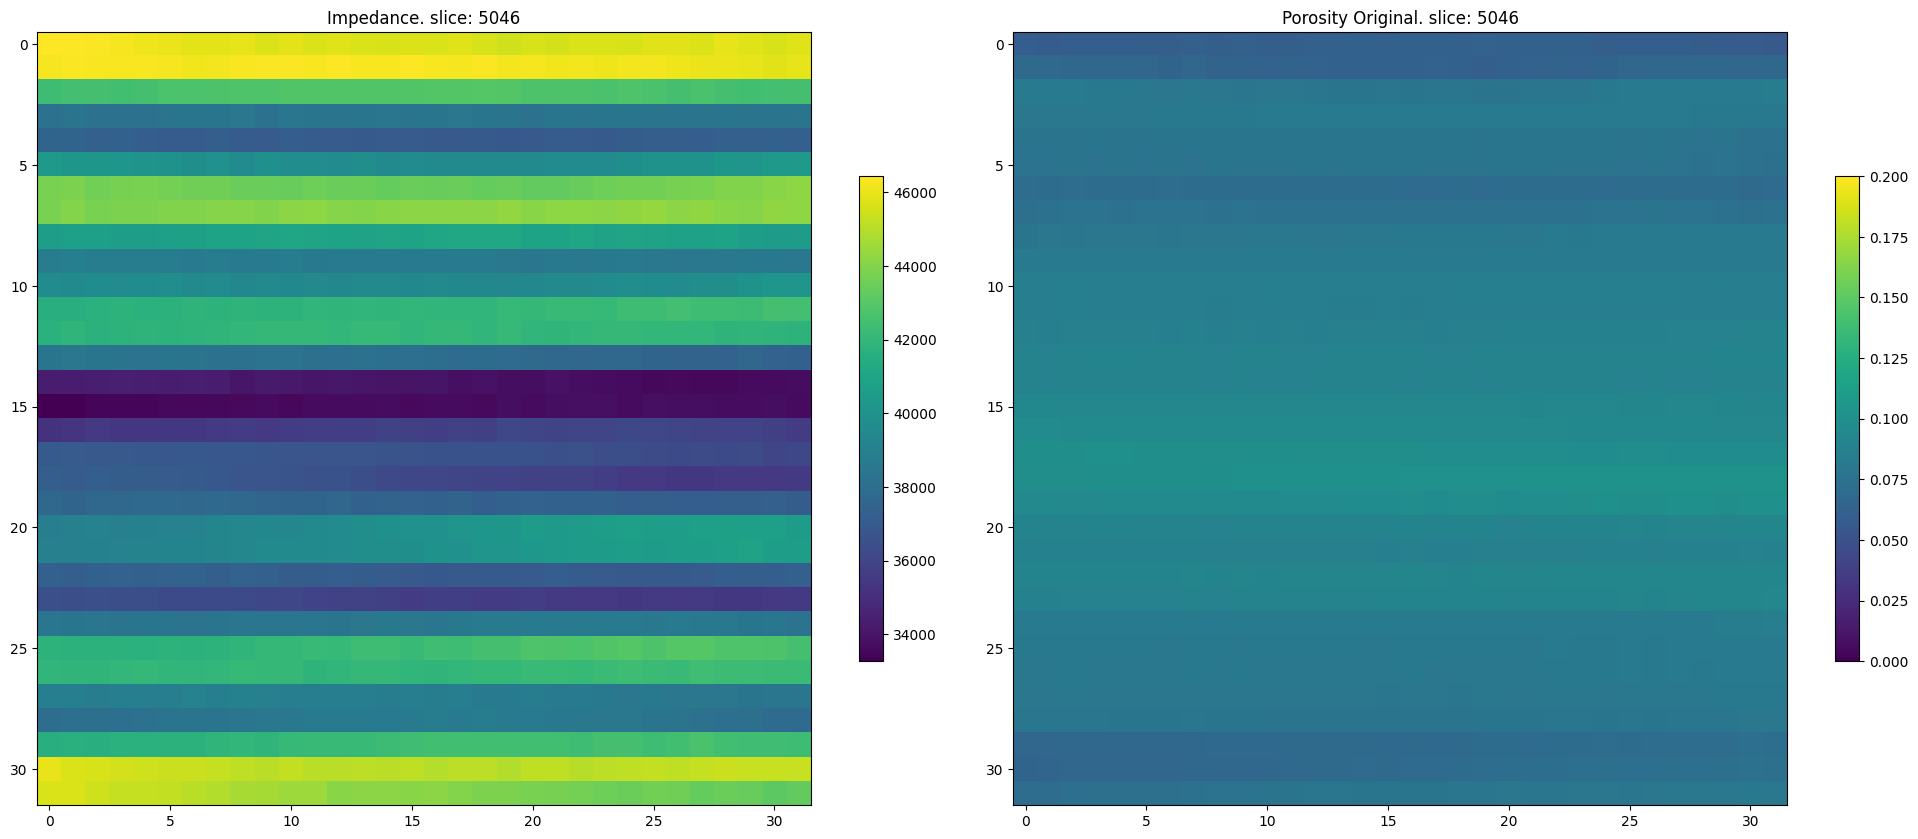

In [60]:
plot_results(X_train,Y_train, Y_train,False, False)

In [26]:
print(f'El shape del X_train es: {X_train.shape}')
print(f'El shape del X_test es: {X_test.shape}')

print(f'El shape del Y_train es: {Y_train.shape}')
print(f'El shape del Y_test es: {Y_test.shape}')

El shape del X_train es: (9746, 32, 32)
El shape del X_test es: (2437, 32, 32)
El shape del Y_train es: (9746, 32, 32)
El shape del Y_test es: (2437, 32, 32)


In [27]:
np.save(f'{folder_output}train/impedance.npy', X_train)
np.save(f'{folder_output}train/porosity.npy', Y_train)

np.save(f'{folder_output}test/impedance.npy', X_test)
np.save(f'{folder_output}test/porosity.npy', Y_test)
